In [1]:
import ssl
import certifi

#fix pt ssl de pe mac ca sa putem desc modelul
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

import os
import cv2 
import pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [2]:
class OpennessDataset(Dataset):
    def __init__(self, root_dir, transform=None, subset_fraction=1.0):
        # subset_fraction: cat la suta din date folosim
        self.samples = []
        self.transform = transform
        
        all_files = []
        
        if not os.path.exists(root_dir):
            raise RuntimeError(f"nu gaseste folderul: {root_dir}")

        for subject in sorted(os.listdir(root_dir)):
            subject_path = os.path.join(root_dir, subject)
            if not os.path.isdir(subject_path):
                continue

            for file in os.listdir(subject_path):
                if file.endswith(".png"):
                    img_path = os.path.join(subject_path, file)
                    pkl_path = img_path.replace(".png", ".pkl")
                    
                    if os.path.exists(pkl_path):
                        all_files.append((img_path, pkl_path))

        #taiem datele si le amestecam
        np.random.seed(42) 
        np.random.shuffle(all_files)
        
        #aleg procentul de date
        num_to_keep = int(len(all_files) * subset_fraction)
        self.samples = all_files[:num_to_keep]

        print(f"dataset facut: folosim {len(self.samples)} imagini ({subset_fraction*100}%)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, pkl_path = self.samples[idx]

        #citire
        img = cv2.imread(img_path)
        if img is None:
            return torch.zeros((3, 64, 64)), torch.tensor([0.0]) #fallback
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        #citim eticheta
        with open(pkl_path, 'rb') as f:
            data = pickle.load(f)
            
            #ne fol de ldmks
            lids = np.array(data['ldmks']['ldmks_lids_2d'])
            
            #calc dist
            y_coords = lids[:, 1]
            openness_pixels = np.max(y_coords) - np.min(y_coords)
            
            #normalizam
            label_val = openness_pixels / 100.0 
            label = torch.tensor([label_val], dtype=torch.float32)

        if self.transform:
            img = self.transform(img)

        return img, label

In [3]:
class OpennessResNet(nn.Module):
    def __init__(self):
        super().__init__()
        #descarc resnet
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        #schimbat ultimul strat sa scoata doar o val
        self.backbone.fc = nn.Linear(512, 1)

    def forward(self, x):
        return self.backbone(x)

incepem studiul pt: [10, 25, 50, 75, 100]% din date

---> Start rulare pentru 10% date...

porneste cu 10.0% din date
dataset facut: folosim 1138 imagini (10.0%)


Epoca 1/5: 100%|██████████| 18/18 [00:05<00:00,  3.35it/s, loss=0.0482]


final 1 -> eroare medie: 1.176732


Epoca 2/5: 100%|██████████| 18/18 [00:02<00:00,  6.59it/s, loss=0.00373]


final 2 -> eroare medie: 0.018195


...

final 3 -> eroare medie: 0.001116


Epoca 4/5: 100%|██████████| 178/178 [00:23<00:00,  7.70it/s, loss=0.000912]


final 4 -> eroare medie: 0.001049


Epoca 5/5: 100%|██████████| 178/178 [00:23<00:00,  7.73it/s, loss=0.00136] 


final 5 -> eroare medie: 0.001207
am terminat!


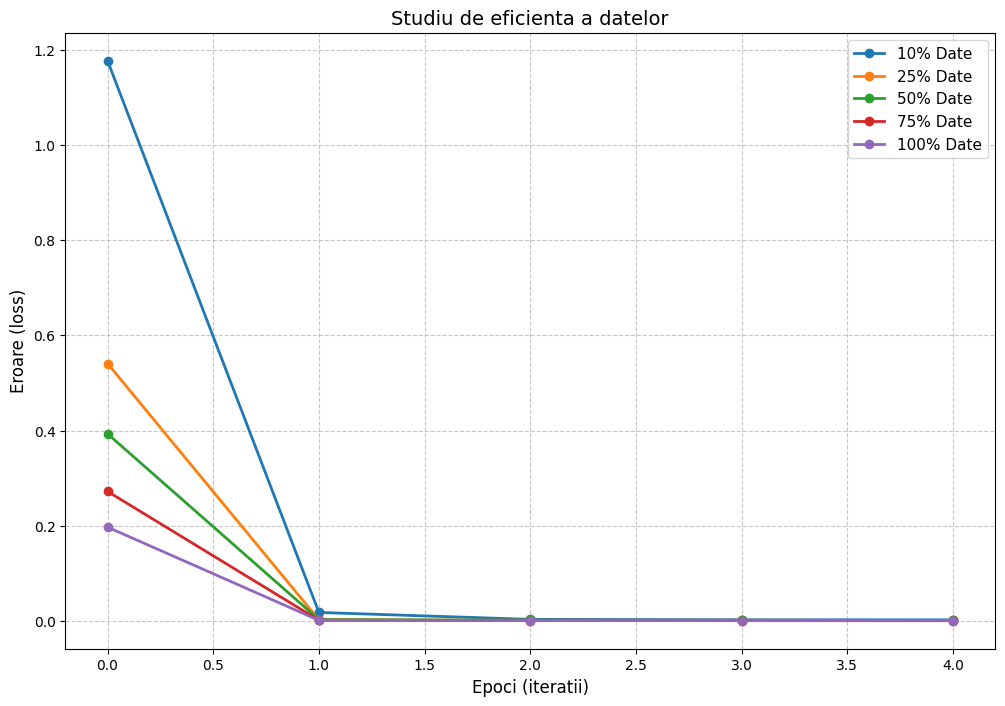

In [4]:
#aleg pe ce lucreaza (mps pt mac)
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

def run_experiment(subset_percent, epochs=5):
    print(f"\nporneste cu {subset_percent*100}% din date")
    
    ROOT_DIR = "/Users/tudorapostol/Documents/Facultate/Y3S1/AMI/SynthEyes_data" 
    BATCH_SIZE = 64
    
    #transf imagini (64x64 pt viteza)
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    #facem datasetul
    dataset = OpennessDataset(ROOT_DIR, transform=transform, subset_fraction=subset_percent)
    
    #dataloader cu num workers 0 pt mac
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    #init model
    model = OpennessResNet().to(device)
    
    #setarile pt antrenare Loss=MSE pt regresie
    criterion = nn.MSELoss() 
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    #bucla de antrenare
    loss_history = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        #bara pt prograes
        loop = tqdm(dataloader, desc=f"Epoca {epoch+1}/{epochs}", leave=True)
        
        for images, labels in loop:
            images = images.to(device)
            labels = labels.to(device)

            #forward pt rpedictie
            outputs = model(images)
            loss = criterion(outputs, labels)

            #backward pt invatare
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        avg_loss = running_loss / len(dataloader)
        loss_history.append(avg_loss)
        print(f"final {epoch+1} -> eroare medie: {avg_loss:.6f}")

    print("am terminat!")
    return loss_history


#procentele pe care le testam
procente = [0.10, 0.25, 0.50, 0.75, 1.0]
rezultate = {}

print(f"incepem studiul pt: {[int(p*100) for p in procente]}% din date")

for p in procente:
    print(f"\n---> Start rulare pentru {int(p*100)}% date...")
    loss_history = run_experiment(subset_percent=p, epochs=5)
    
    rezultate[p] = loss_history #salvam rez intr-un dict

#generare grafic
plt.figure(figsize=(12, 8))

for p, loss in rezultate.items():
    eticheta = f"{int(p*100)}% Date"
    plt.plot(loss, label=eticheta, marker='o', linewidth=2)

plt.xlabel("Epoci (iteratii)", fontsize=12)
plt.ylabel("Eroare (loss)", fontsize=12)
plt.title("Studiu de eficienta a datelor", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

#salveaza graficul ca png
plt.savefig("Grafic_Final_Eficienta.png", dpi=300)

plt.show()